# Proyecto Final

En base al ejercicio práctico de la clase 3, aplique la segmentación de imágenes con el algoritmo kmeans solo al área de interés del conjunto de entrenamiento (trainset) y encuentre los 3 o 4 clústers del área de interés y exporte su centro, valor máximo y mínimo.

Con los valores obtenidos de cada clúster, aplíquelos al conjunto de prueba (testset) y observe si su desarrollo se acopla a todas las imágenes.

 

Responde las preguntas:

¿Sus criterios en la selección de filtros para seleccionar el área de interés en las imágenes fueron adecuados? Justifique su respuesta.

¿ El tiempo de entrenamiento del algoritmo kmeans fué menor al usar este criterio de selección del área de interés con respecto al realizado en clase? Justifique su respuesta.

¿Qué podría haber mejorado una vez obtenidos los resultados?

### En base a los mejores resultados obtenidos de la tarea 3 , se procede a aplicar Filtro Gaussiano + Umbral fijo + Segmentacion Watershed

Funciones del ejercicio practico 3

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

def norm_u8(x):
    x = x.astype(np.float32)
    mn, mx = np.min(x), np.max(x)
    if mx - mn < 1e-6:
        return np.zeros_like(x, dtype=np.uint8)
    x = (x - mn) / (mx - mn)
    return (x * 255).astype(np.uint8)

In [49]:
def watershed_pipeline_steps(gray, k=3, thr=30, invert=False,
                             open_ks=3, open_iter=1,
                             dist_frac=0.35):
    """
    Devuelve todos los pasos intermedios para graficar.
    """
    g8 = norm_u8(gray)
    k = k if k % 2 == 1 else k + 1
    blur = cv2.GaussianBlur(g8, (k, k), 0)

    mode = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, roi_bin = cv2.threshold(blur, thr, 255, mode)

    # limpieza ligera
    if open_ks and open_ks > 1:
        open_ks = open_ks if open_ks % 2 == 1 else open_ks + 1
        se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_ks, open_ks))
        roi_bin = cv2.morphologyEx(roi_bin, cv2.MORPH_OPEN, se, iterations=open_iter)

    img_color = cv2.cvtColor(g8, cv2.COLOR_GRAY2BGR)

    # sure background
    se_bg = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    sure_bg = cv2.dilate(roi_bin, se_bg, iterations=2)

    # sure foreground via distance transform
    dist = cv2.distanceTransform(roi_bin, cv2.DIST_L2, 5)
    dist_norm = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)

    _, sure_fg = cv2.threshold(dist_norm, dist_frac, 1.0, cv2.THRESH_BINARY)
    sure_fg = (sure_fg * 255).astype(np.uint8)

    unknown = cv2.subtract(sure_bg, sure_fg)

    # markers
    num_labels, markers = cv2.connectedComponents(sure_fg)
    markers = markers.astype(np.int32)
    markers = markers + 1
    markers[unknown == 255] = 0

    markers_in = markers.copy()
    ws = cv2.watershed(img_color, markers)

    # final mask
    final = np.zeros_like(g8, dtype=np.uint8)
    final[ws > 1] = 255

    # overlay watershed borders on original (in red)
    overlay = img_color.copy()
    overlay[ws == -1] = (0, 0, 255)

    # markers visualization (normalize to 0..255 for display)
    mk = markers_in.astype(np.float32)
    mk[mk < 0] = 0
    mk_vis = cv2.normalize(mk, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return {
        "orig": g8,
        "blur": blur,
        "roi_bin": roi_bin,
        "sure_bg": sure_bg,
        "sure_fg": sure_fg,
        "unknown": unknown,
        "markers_vis": mk_vis,
        "ws_overlay_bgr": overlay,
        "final": final
    }

def plot_steps_grid(paths, k=3, thr=30, dist_frac=0.35, invert=False):
    steps_order = [
        ("orig", "0) Original"),
        ("blur", "1) Gauss"),
        ("roi_bin", "2) ROI bin (thr fijo)"),
        ("sure_bg", "3) Sure BG"),
        ("sure_fg", "4) Sure FG"),
        ("unknown", "5) Unknown"), #Zona insegura
        ("markers_vis", "6) Markers"),
        ("ws_overlay_bgr", "7) Watershed bordes"),
        ("final", "8) Final mask"),
    ]

    n = len(paths)
    cols = len(steps_order)
    fig, axes = plt.subplots(n, cols, figsize=(3.0 * cols, 3.0 * n))

    if n == 1:
        axes = np.expand_dims(axes, 0)

    for i, p in enumerate(paths):
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"No pude leer: {p}")
            continue

        out = watershed_pipeline_steps(img, k=k, thr=thr, dist_frac=dist_frac, invert=invert)

        for j, (key, title) in enumerate(steps_order):
            ax = axes[i, j]
            ax.set_axis_off()

            if key == "ws_overlay_bgr":
                # convertir BGR->RGB para matplotlib
                rgb = cv2.cvtColor(out[key], cv2.COLOR_BGR2RGB)
                ax.imshow(rgb)
            else:
                ax.imshow(out[key], cmap="gray", vmin=0, vmax=255)

            if i == 0:
                ax.set_title(title, fontsize=10)

        # etiqueta con nombre de archivo al inicio de la fila
        axes[i, 0].text(
            0.02, -0.08, os.path.basename(p),
            transform=axes[i, 0].transAxes, fontsize=9
        )

    plt.tight_layout()
    plt.show()

Se aplica filtros, y se crea máscara e imagenes enmascaradas en carpetas

In [50]:
import os, glob
import cv2
import numpy as np
from pathlib import Path

# ---------- Config ----------
TRAIN_DIR = r"train"
OUT_MASK_DIR   = r"train_masks_ws"    # máscaras 0/255
OUT_MASKED_DIR = r"train_masked_ws"   # imagen original aplicada con máscara

exts = ("*.tif", "*.tiff")



# Parámetros 
K = 3
THR = 30
DIST_FRAC = 0.35
INVERT = False

# ---------- Util ----------
def ensure_dir(p):
    os.makedirs(p, exist_ok=True)

ensure_dir(OUT_MASK_DIR)
ensure_dir(OUT_MASKED_DIR)

# ---------- Recolectar imágenes ----------
all_imgs = []
for e in exts:
    all_imgs.extend(glob.glob(os.path.join(TRAIN_DIR, "**", e), recursive=True))

if len(all_imgs) == 0:
    raise FileNotFoundError(f"No encontré imágenes en: {TRAIN_DIR}")

print("Total imágenes encontradas:", len(all_imgs))

# ---------- Procesar ----------
n_ok, n_fail = 0, 0

for idx, p in enumerate(all_imgs, 1):
    try:
        # Leer como "unchanged" para respetar bit-depth si es TIFF 16-bit
        img = cv2.imread(p, cv2.IMREAD_UNCHANGED)
        if img is None:
            print("No pude leer:", p)
            n_fail += 1
            continue

        # Asegurar escala de grises
        if img.ndim == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            gray = img

        # 1) obtener pasos y máscara final (0/255)
        out = watershed_pipeline_steps(gray, k=K, thr=THR, dist_frac=DIST_FRAC, invert=INVERT)
        mask = out["final"]  # uint8 0/255 (tamaño igual a gray)

        # 2) aplicar máscara al original conservando bitdepth:
        #    mask255 -> mask01 -> multiplicación
        mask01 = (mask > 0).astype(np.uint8)

        if gray.dtype == np.uint8:
            masked = cv2.bitwise_and(gray, gray, mask=mask)
        else:
            # Para 16-bit u otros: multiplicación por 0/1
            masked = (gray * mask01).astype(gray.dtype)

        # 3) construir nombres de salida (manteniendo estructura simple)
        base = Path(p).stem

        # Guardar máscara (PNG)
        mask_path = os.path.join(OUT_MASK_DIR, f"{base}_mask.png")
        cv2.imwrite(mask_path, mask)

        # Guardar imagen enmascarada (TIFF)
        masked_path = os.path.join(OUT_MASKED_DIR, f"{base}_masked.tif")
        cv2.imwrite(masked_path, masked)

        n_ok += 1
        if idx % 50 == 0 or idx == len(all_imgs):
            print(f"[{idx}/{len(all_imgs)}] OK={n_ok} FAIL={n_fail}")

    except Exception as ex:
        print("Error en:", p, "|", ex)
        n_fail += 1

print("Listo ✅  OK:", n_ok, " FAIL:", n_fail)
print("Máscaras en:", OUT_MASK_DIR)
print("Enmascaradas en:", OUT_MASKED_DIR)

Total imágenes encontradas: 277
[50/277] OK=50 FAIL=0
[100/277] OK=100 FAIL=0
[150/277] OK=150 FAIL=0
[200/277] OK=200 FAIL=0
[250/277] OK=250 FAIL=0
[277/277] OK=277 FAIL=0
Listo ✅  OK: 277  FAIL: 0
Máscaras en: train_masks_ws
Enmascaradas en: train_masked_ws


Observacion de 5 imagenes (mascara y imagen enmascarada)

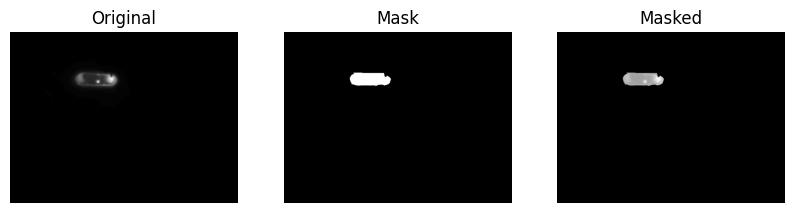

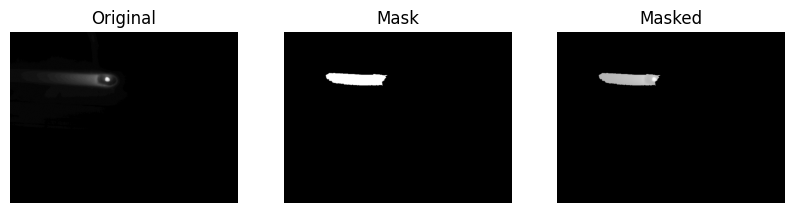

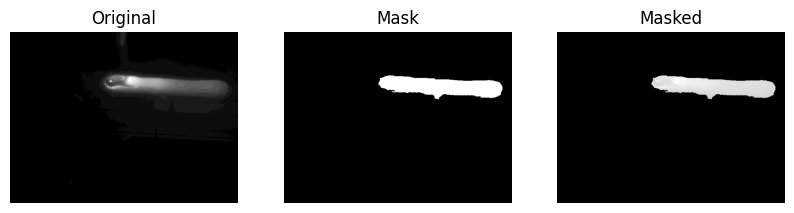

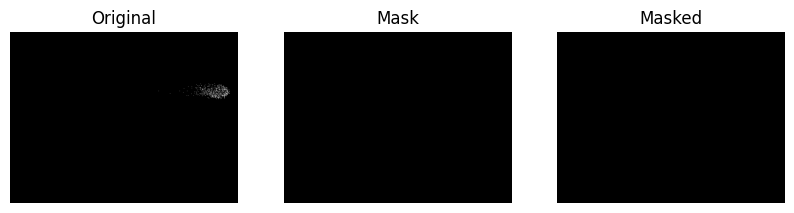

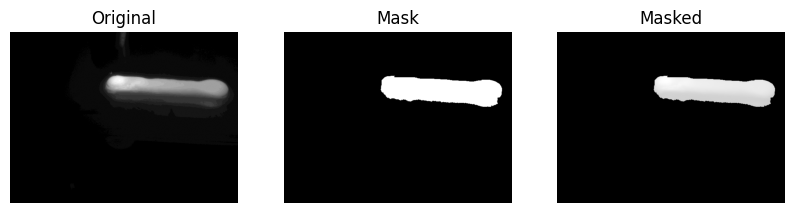

In [51]:
import random
import matplotlib.pyplot as plt

# toma 3 random de los originales procesados
some = random.sample(all_imgs, 5)

for p in some:
    base = Path(p).stem
    m = cv2.imread(os.path.join(OUT_MASK_DIR, f"{base}_mask.png"), cv2.IMREAD_GRAYSCALE)
    im = cv2.imread(os.path.join(OUT_MASKED_DIR, f"{base}_masked.tif"), cv2.IMREAD_UNCHANGED)

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1); plt.title("Original"); plt.imshow(cv2.imread(p, cv2.IMREAD_GRAYSCALE), cmap="gray"); plt.axis("off")
    plt.subplot(1,3,2); plt.title("Mask"); plt.imshow(m, cmap="gray"); plt.axis("off")
    plt.subplot(1,3,3); plt.title("Masked"); plt.imshow(im, cmap="gray"); plt.axis("off")
    plt.show()

Entrenamiento en Kmeans solo en ROI (4 Clusters)

In [52]:
import os, glob, random
import cv2
import numpy as np

def load_img_and_mask(img_path, mask_dir):
    base = os.path.splitext(os.path.basename(img_path))[0]
    mask_path = os.path.join(mask_dir, f"{base}_mask.png")
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if img is None or mask is None:
        return None, None
    roi = (mask > 0)
    return img, roi

def train_kmeans_centers_roi(train_dir, mask_dir, n_clusters=4,
                             max_imgs=300, samples_per_img=6000, seed=42,
                             out_path="kmeans_centers_roi.npy"):
    # recolectar paths
    paths = []
    for e in ("*.tif","*.tiff"):
        paths += glob.glob(os.path.join(train_dir, "**", e), recursive=True)
    if len(paths) == 0:
        raise FileNotFoundError(f"No encontré imágenes en: {train_dir}")

    random.seed(seed)
    paths = random.sample(paths, k=min(max_imgs, len(paths)))

    samples = []
    for p in paths:
        img, roi = load_img_and_mask(p, mask_dir)
        if img is None:
            continue

        pix = img[roi]  # SOLO ROI
        if pix.size == 0:
            continue

        n = min(samples_per_img, pix.size)
        idx = np.random.choice(pix.size, size=n, replace=False)
        samples.append(pix[idx])

    if len(samples) == 0:
        raise RuntimeError("No pude recolectar muestras ROI. Revisa máscaras y paths.")

    X = np.concatenate(samples).astype(np.float32).reshape(-1,1)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 200, 0.1)
    compactness, labels, centers = cv2.kmeans(X, n_clusters, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    centers = np.sort(centers.flatten())  # ordenar por intensidad

    np.save(out_path, centers)
    print("Centros ROI guardados en:", out_path)
    print("Centers:", centers)
    print("Muestras ROI:", X.shape[0])
    return centers

In [53]:
def assign_clusters_roi(img_u8, roi_bool, centers):
    """
    Devuelve:
      labels_roi: imagen labels con -1 fuera del ROI, 0..K-1 dentro.
    """
    H, W = img_u8.shape
    K = len(centers)
    labels_roi = np.full((H, W), -1, dtype=np.int16)

    pix = img_u8[roi_bool].astype(np.float32)[:, None]  # (N,1)
    c = np.asarray(centers, dtype=np.float32)[None, :]  # (1,K)
    d = np.abs(pix - c)                                 # (N,K)
    lab = np.argmin(d, axis=1).astype(np.int16)         # (N,)

    labels_roi[roi_bool] = lab
    return labels_roi

def cluster_centroids_roi(labels_roi, K):
    """
    centroides geométricos SOLO para clusters dentro del ROI.
    """
    stats = []
    for k in range(K):
        ys, xs = np.where(labels_roi == k)
        area = len(xs)
        if area == 0:
            stats.append({"cluster": k, "area": 0, "cx": np.nan, "cy": np.nan})
            continue
        stats.append({"cluster": k, "area": area, "cx": xs.mean(), "cy": ys.mean()})
    return stats

In [54]:
import matplotlib.pyplot as plt

def show_clusters_roi(image_path, mask_dir, centers_path="kmeans_centers_roi.npy"):
    centers = np.load(centers_path)
    img, roi = load_img_and_mask(image_path, mask_dir)
    if img is None:
        print("No pude cargar imagen/máscara")
        return

    labels_roi = assign_clusters_roi(img, roi, centers)
    K = len(centers)
    stats = cluster_centroids_roi(labels_roi, K)

    # visualización: fuera del ROI queda negro (0), dentro queda label+1 (para que 0 sea cluster0)
    vis = np.zeros_like(img, dtype=np.uint8)
    vis[roi] = (labels_roi[roi] + 1).astype(np.uint8)  # 1..K

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); plt.title("Original"); plt.imshow(img, cmap="gray"); plt.axis("off")
    plt.subplot(1,2,2); plt.title("Clusters (solo ROI) + centroides")
    plt.imshow(vis, cmap="nipy_spectral"); plt.axis("off")

    for s in stats:
        if np.isfinite(s["cx"]):
            plt.plot(s["cx"], s["cy"], "wo", markersize=4)
            plt.text(s["cx"], s["cy"], f'c{s["cluster"]}', color="white", fontsize=8)

    plt.show()

In [55]:
import pandas as pd

def folder_features_roi(img_dir, mask_dir, centers_path="kmeans_centers_roi.npy",
                        out_csv="features_roi_long.csv"):
    centers = np.load(centers_path)
    K = len(centers)

    paths = []
    for e in ("*.tif","*.tiff"):
        paths += glob.glob(os.path.join(img_dir, "**", e), recursive=True)

    rows = []
    for p in paths:
        img, roi = load_img_and_mask(p, mask_dir)
        if img is None:
            continue

        labels_roi = assign_clusters_roi(img, roi, centers)
        stats = cluster_centroids_roi(labels_roi, K)

        for s in stats:
            rows.append({
                "file": os.path.basename(p),
                "cluster": s["cluster"],
                "center_intensity": float(centers[s["cluster"]]),
                "area": s["area"],
                "cx": s["cx"],
                "cy": s["cy"],
            })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print("Guardado:", out_csv, "filas:", len(df))
    return df

In [56]:
centers = train_kmeans_centers_roi("train", "train_masks_ws", n_clusters=4, out_path="kmeans_centers_roi.npy")

Centros ROI guardados en: kmeans_centers_roi.npy
Centers: [ 86.537735  94.7017   106.562355 121.663506]
Muestras ROI: 1309927


In [57]:
import os, glob
import cv2
import numpy as np
import pandas as pd

def export_cluster_ranges_roi(train_dir, mask_dir, centers_path="kmeans_centers_roi.npy",
                              out_csv="kmeans_centers_roi_ranges.csv",
                              exts=("*.tif","*.tiff")):
    centers = np.load(centers_path).astype(np.float32)
    K = len(centers)

    # init min/max por cluster
    cmin = np.full(K, np.inf, dtype=np.float32)
    cmax = np.full(K, -np.inf, dtype=np.float32)
    count = np.zeros(K, dtype=np.int64)

    # recolectar imágenes
    paths = []
    for e in exts:
        paths += glob.glob(os.path.join(train_dir, "**", e), recursive=True)
    if len(paths) == 0:
        raise FileNotFoundError(f"No encontré imágenes en: {train_dir}")

    for p in paths:
        base = os.path.splitext(os.path.basename(p))[0]
        mask_path = os.path.join(mask_dir, f"{base}_mask.png")

        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if img is None or mask is None:
            continue

        roi = mask > 0
        pix = img[roi]
        if pix.size == 0:
            continue

        # asignación a clusters por distancia a centers (en intensidad)
        pix_f = pix.astype(np.float32)[:, None]          # (N,1)
        d = np.abs(pix_f - centers[None, :])             # (N,K)
        lab = np.argmin(d, axis=1).astype(np.int32)      # (N,)

        # actualizar min/max por cluster
        for k in range(K):
            pk = pix[lab == k]
            if pk.size == 0:
                continue
            vmin = float(pk.min())
            vmax = float(pk.max())
            if vmin < cmin[k]: cmin[k] = vmin
            if vmax > cmax[k]: cmax[k] = vmax
            count[k] += pk.size

    # arreglar clusters sin datos
    cmin[np.isinf(cmin)] = np.nan
    cmax[np.isinf(-cmax)] = np.nan  # por si acaso
    cmax[cmax == -np.inf] = np.nan

    df = pd.DataFrame({
        "cluster": np.arange(K),
        "center": centers,
        "min": cmin,
        "max": cmax,
        "count_pixels": count
    })

    df.to_csv(out_csv, index=False)
    print("Exportado:", out_csv)
    return df

In [58]:
centers = train_kmeans_centers_roi("train", "train_masks_ws", n_clusters=4, out_path="kmeans_centers_roi.npy")
df_ranges = export_cluster_ranges_roi("train", "train_masks_ws", "kmeans_centers_roi.npy",
                                      out_csv="kmeans_centers_roi_ranges.csv")
df_ranges

Centros ROI guardados en: kmeans_centers_roi.npy
Centers: [ 86.5411   94.70093 106.56683 121.67267]
Muestras ROI: 1309927
Exportado: kmeans_centers_roi_ranges.csv


,cluster,center,min,max,count_pixels
0,0,86.541100,80.0,90.0,1222954
1,1,94.700928,91.0,100.0,1019928
2,2,106.566833,101.0,114.0,551627
3,3,121.672668,115.0,171.0,149772


In [59]:
df_train = folder_features_roi("train", "train_masks_ws", "kmeans_centers_roi.npy", "train_features_roi_long.csv")

Guardado: train_features_roi_long.csv filas: 1108


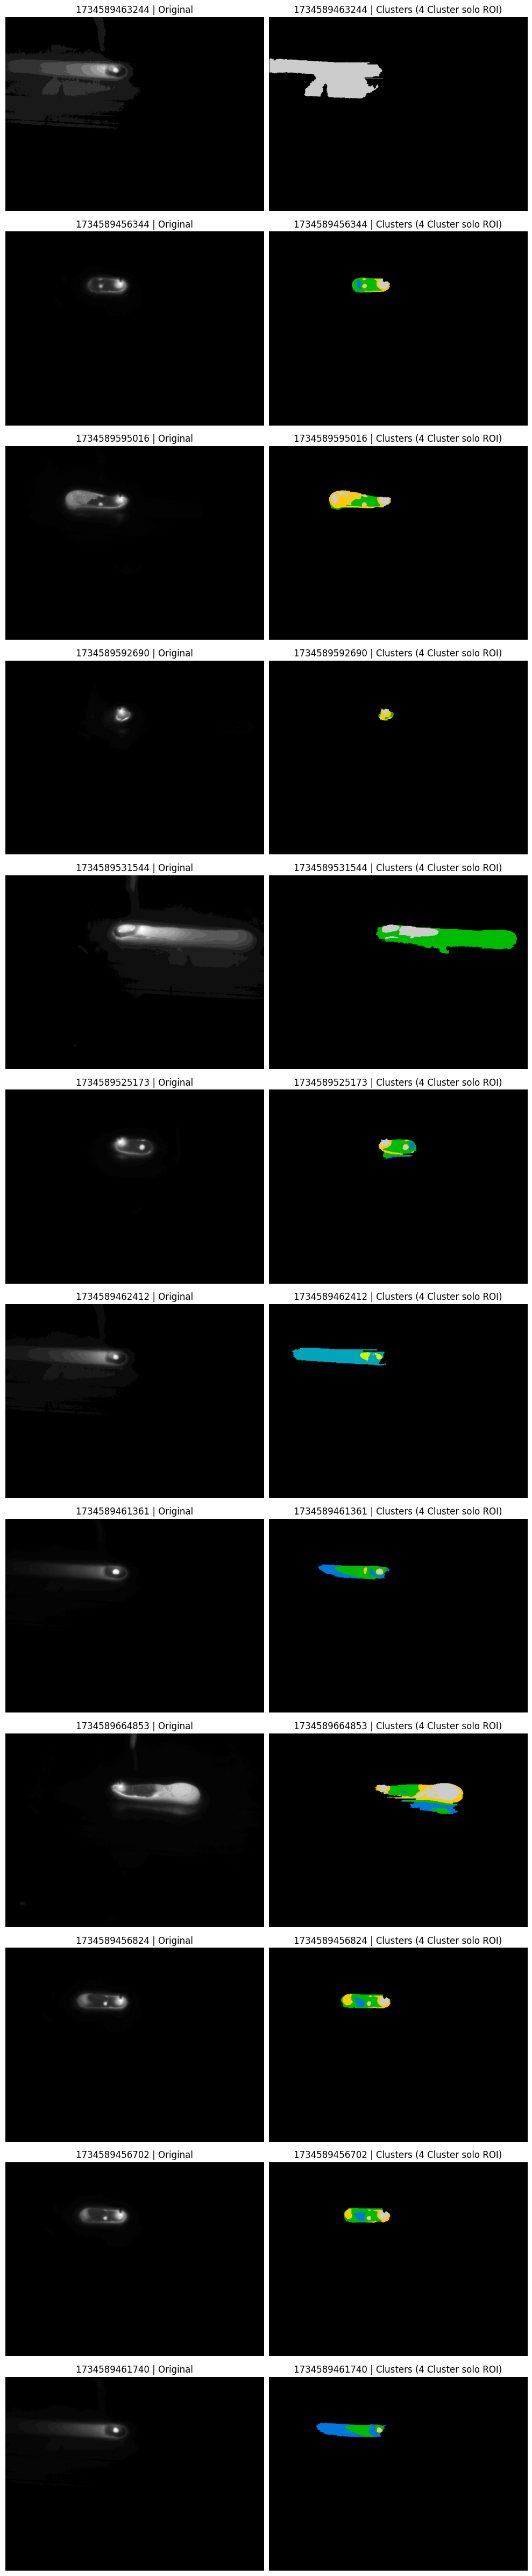

In [60]:
import os, glob, random
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_10_random_clusters_roi(img_dir, mask_dir, centers_path="kmeans_centers_roi.npy",
                                n=12, seed=42, exts=("*.tif","*.tiff")):
    centers = np.load(centers_path)
    K = len(centers)

    # recolectar imágenes
    paths = []
    for e in exts:
        paths += glob.glob(os.path.join(img_dir, "**", e), recursive=True)
    if len(paths) == 0:
        raise FileNotFoundError(f"No encontré imágenes en: {img_dir}")

    random.seed(seed)
    sample_paths = random.sample(paths, k=min(n, len(paths)))

    fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, 4 * len(sample_paths)))

    if len(sample_paths) == 1:
        axes = np.expand_dims(axes, 0)

    for i, p in enumerate(sample_paths):
        base = os.path.splitext(os.path.basename(p))[0]
        mask_path = os.path.join(mask_dir, f"{base}_mask.png")

        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            # si falta algo, lo saltamos pero dejamos una marca visual
            axes[i, 0].set_title(f"{base} (faltó img o mask)")
            axes[i, 0].axis("off")
            axes[i, 1].axis("off")
            continue

        roi = (mask > 0)

        # asignar clusters SOLO dentro del ROI (fuera queda -1)
        labels_roi = np.full(img.shape, -1, dtype=np.int16)
        pix = img[roi].astype(np.float32)[:, None]
        c = centers.astype(np.float32)[None, :]
        lab = np.argmin(np.abs(pix - c), axis=1).astype(np.int16)
        labels_roi[roi] = lab

        # visualización: negro fuera del ROI
        vis = np.zeros_like(img, dtype=np.uint8)
        vis[roi] = (labels_roi[roi] + 1).astype(np.uint8)  # 1..K dentro

        # plot
        axes[i, 0].imshow(img, cmap="gray")
        axes[i, 0].set_title(f"{base} | Original")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(vis, cmap="nipy_spectral")
        axes[i, 1].set_title(f"{base} | Clusters (4 Cluster solo ROI)")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


# Ejemplo:
plot_10_random_clusters_roi("train", "train_masks_ws", "kmeans_centers_roi.npy", n=12)

Guardar todas las imagenes de train con cluster (4)

In [61]:
import os, glob
import cv2
import numpy as np
from pathlib import Path

# ---------------- CONFIG ----------------
TRAIN_DIR   = r"train"
MASK_DIR    = r"train_masks_ws"            # donde están *_mask.png
CENTERS_NPY = r"kmeans_centers_roi.npy"    # centros aprendidos en TRAIN ROI
OUT_DIR     = r"train_ROI_cluster"         # carpeta nueva

exts = ("*.tif", "*.tiff")
SAVE_AS_TIF = False   # True si quieres .tif, False para .png
# ---------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
centers = np.load(CENTERS_NPY).astype(np.float32)
K = len(centers)

# recolectar imágenes
paths = []
for e in exts:
    paths += glob.glob(os.path.join(TRAIN_DIR, "**", e), recursive=True)

if len(paths) == 0:
    raise FileNotFoundError(f"No encontré imágenes en: {TRAIN_DIR}")

print("Total imágenes:", len(paths))

ok, fail = 0, 0

for i, p in enumerate(paths, 1):
    base = Path(p).stem
    mask_path = os.path.join(MASK_DIR, f"{base}_mask.png")

    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        print(f"[SKIP] Falta img o mask: {base}")
        fail += 1
        continue

    roi = (mask > 0)
    if roi.sum() == 0:
        # ROI vacía -> salida negra
        cluster_vis = np.zeros_like(img, dtype=np.uint8)
    else:
        # asignar clusters SOLO dentro del ROI
        pix = img[roi].astype(np.float32)[:, None]   # (N,1)
        d = np.abs(pix - centers[None, :])           # (N,K)
        lab = np.argmin(d, axis=1).astype(np.uint8)  # 0..K-1

        # imagen de salida: 0 fuera ROI, 1..K dentro (para visualizar con colormap si quieres)
        cluster_vis = np.zeros_like(img, dtype=np.uint8)
        cluster_vis[roi] = lab + 1

    # guardar
    out_ext = ".tif" if SAVE_AS_TIF else ".png"
    vis_scaled = (cluster_vis.astype(np.float32) * (255.0 / max(1, K))).astype(np.uint8)
    out_ext = ".tif" if SAVE_AS_TIF else ".png"
    out_path = os.path.join(OUT_DIR, f"{base}_cluster{out_ext}")  # <-- ESTA LÍNEA FALTABA
    vis_scaled = (cluster_vis.astype(np.float32) * (255.0 / max(1, K))).astype(np.uint8)
    #cv2.imwrite(out_path, vis_scaled)
    color = cv2.applyColorMap((cluster_vis * (255 // max(1, K))).astype(np.uint8), cv2.COLORMAP_TURBO)
    # poner fuera ROI en negro de verdad
    color[cluster_vis == 0] = (0, 0, 0)
    cv2.imwrite(out_path, color)

    ok += 1
    if i % 50 == 0 or i == len(paths):
        print(f"[{i}/{len(paths)}] OK={ok} FAIL={fail}")

print("Listo ✅  Guardadas en:", OUT_DIR)

Total imágenes: 277
[50/277] OK=50 FAIL=0
[100/277] OK=100 FAIL=0
[150/277] OK=150 FAIL=0
[200/277] OK=200 FAIL=0
[250/277] OK=250 FAIL=0
[277/277] OK=277 FAIL=0
Listo ✅  Guardadas en: train_ROI_cluster


7 Clusters

In [62]:
centers = train_kmeans_centers_roi("train", "train_masks_ws", n_clusters=7, out_path="kmeans_centers_roi_7.npy")

Centros ROI guardados en: kmeans_centers_roi_7.npy
Centers: [ 85.35087   91.171974  95.72738  101.321785 107.67015  116.21038
 131.09808 ]
Muestras ROI: 1309927


In [63]:
centers = train_kmeans_centers_roi("train", "train_masks_ws", n_clusters=7, out_path="kmeans_centers_roi_7.npy")
df_ranges = export_cluster_ranges_roi("train", "train_masks_ws", "kmeans_centers_roi_7.npy",
                                      out_csv="kmeans_centers_roi_ranges.csv")
df_ranges

Centros ROI guardados en: kmeans_centers_roi_7.npy
Centers: [ 84.830696  90.352196  95.09516  101.3169   107.67447  116.2075
 131.12398 ]
Muestras ROI: 1309927
Exportado: kmeans_centers_roi_ranges.csv


,cluster,center,min,max,count_pixels
0,0,84.830696,80.0,87.0,903875
1,1,90.352196,88.0,92.0,601342
2,2,95.095161,93.0,98.0,616442
3,3,101.316902,99.0,104.0,320050
4,4,107.674469,105.0,111.0,288657
5,5,116.207497,112.0,123.0,177022
6,6,131.123978,124.0,171.0,36893


In [64]:
df_train = folder_features_roi("train", "train_masks_ws", "kmeans_centers_roi_7.npy", "train_features_roi_long_7.csv")

Guardado: train_features_roi_long_7.csv filas: 1939


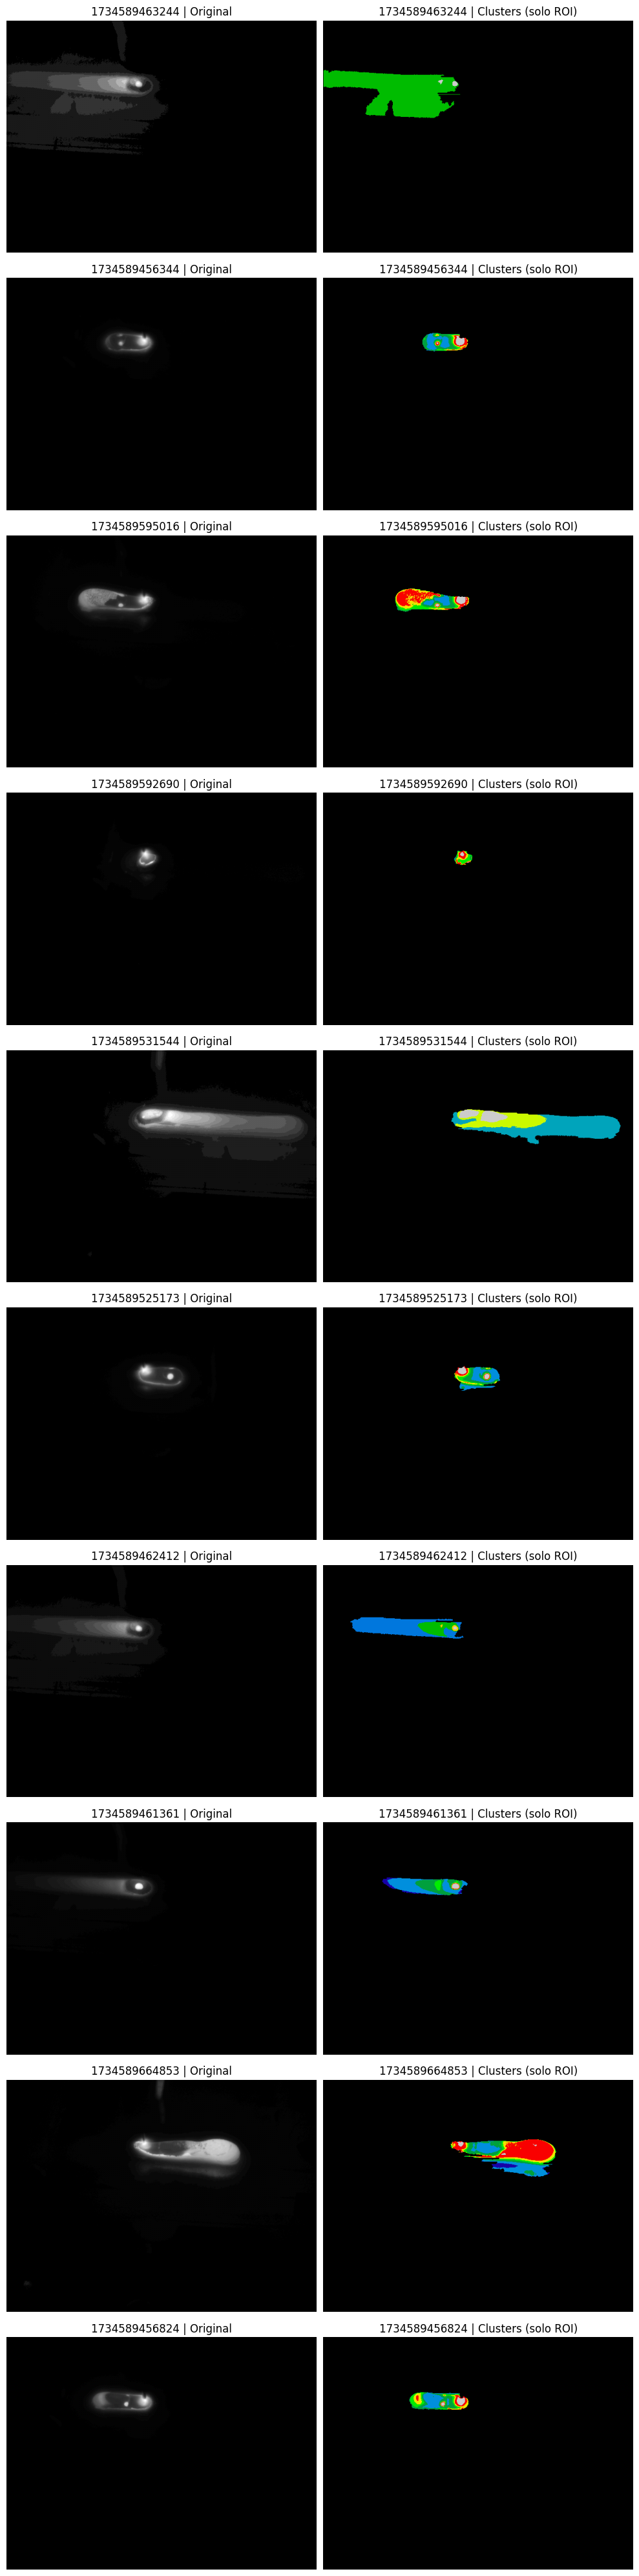

In [65]:
import os, glob, random
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_10_random_clusters_roi(img_dir, mask_dir, centers_path="kmeans_centers_roi_7.npy",
                                n=12, seed=42, exts=("*.tif","*.tiff")):
    centers = np.load(centers_path)
    K = len(centers)

    # recolectar imágenes
    paths = []
    for e in exts:
        paths += glob.glob(os.path.join(img_dir, "**", e), recursive=True)
    if len(paths) == 0:
        raise FileNotFoundError(f"No encontré imágenes en: {img_dir}")

    random.seed(seed)
    sample_paths = random.sample(paths, k=min(n, len(paths)))

    fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, 4 * len(sample_paths)))

    if len(sample_paths) == 1:
        axes = np.expand_dims(axes, 0)

    for i, p in enumerate(sample_paths):
        base = os.path.splitext(os.path.basename(p))[0]
        mask_path = os.path.join(mask_dir, f"{base}_mask.png")

        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            # si falta algo, lo saltamos pero dejamos una marca visual
            axes[i, 0].set_title(f"{base} (faltó img o mask)")
            axes[i, 0].axis("off")
            axes[i, 1].axis("off")
            continue

        roi = (mask > 0)

        # asignar clusters SOLO dentro del ROI (fuera queda -1)
        labels_roi = np.full(img.shape, -1, dtype=np.int16)
        pix = img[roi].astype(np.float32)[:, None]
        c = centers.astype(np.float32)[None, :]
        lab = np.argmin(np.abs(pix - c), axis=1).astype(np.int16)
        labels_roi[roi] = lab

        # visualización: negro fuera del ROI
        vis = np.zeros_like(img, dtype=np.uint8)
        vis[roi] = (labels_roi[roi] + 1).astype(np.uint8)  # 1..K dentro

        # plot
        axes[i, 0].imshow(img, cmap="gray")
        axes[i, 0].set_title(f"{base} | Original")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(vis, cmap="nipy_spectral")
        axes[i, 1].set_title(f"{base} | Clusters (solo ROI)")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


# Ejemplo:
plot_10_random_clusters_roi("train", "train_masks_ws", "kmeans_centers_roi_7.npy", n=10)

Guardar todas las imagenes de test con cluster (7)

In [66]:
import os, glob
import cv2
import numpy as np
from pathlib import Path

# ---------------- CONFIG ----------------
TRAIN_DIR   = r"train"
MASK_DIR    = r"train_masks_ws"            # donde están *_mask.png
CENTERS_NPY = r"kmeans_centers_roi_7.npy"    # centros aprendidos en TRAIN ROI
OUT_DIR     = r"train_ROI_cluster_7"         # carpeta nueva

exts = ("*.tif", "*.tiff")
SAVE_AS_TIF = False   # True si quieres .tif, False para .png
# ---------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
centers = np.load(CENTERS_NPY).astype(np.float32)
K = len(centers)

# recolectar imágenes
paths = []
for e in exts:
    paths += glob.glob(os.path.join(TRAIN_DIR, "**", e), recursive=True)

if len(paths) == 0:
    raise FileNotFoundError(f"No encontré imágenes en: {TRAIN_DIR}")

print("Total imágenes:", len(paths))

ok, fail = 0, 0

for i, p in enumerate(paths, 1):
    base = Path(p).stem
    mask_path = os.path.join(MASK_DIR, f"{base}_mask.png")

    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        print(f"[SKIP] Falta img o mask: {base}")
        fail += 1
        continue

    roi = (mask > 0)
    if roi.sum() == 0:
        # ROI vacía -> salida negra
        cluster_vis = np.zeros_like(img, dtype=np.uint8)
    else:
        # asignar clusters SOLO dentro del ROI
        pix = img[roi].astype(np.float32)[:, None]   # (N,1)
        d = np.abs(pix - centers[None, :])           # (N,K)
        lab = np.argmin(d, axis=1).astype(np.uint8)  # 0..K-1

        # imagen de salida: 0 fuera ROI, 1..K dentro (para visualizar con colormap si quieres)
        cluster_vis = np.zeros_like(img, dtype=np.uint8)
        cluster_vis[roi] = lab + 1

    # guardar
    out_ext = ".tif" if SAVE_AS_TIF else ".png"
    vis_scaled = (cluster_vis.astype(np.float32) * (255.0 / max(1, K))).astype(np.uint8)
    out_ext = ".tif" if SAVE_AS_TIF else ".png"
    out_path = os.path.join(OUT_DIR, f"{base}_cluster{out_ext}")  # <-- ESTA LÍNEA FALTABA
    vis_scaled = (cluster_vis.astype(np.float32) * (255.0 / max(1, K))).astype(np.uint8)
    #cv2.imwrite(out_path, vis_scaled)
    color = cv2.applyColorMap((cluster_vis * (255 // max(1, K))).astype(np.uint8), cv2.COLORMAP_TURBO)
    # poner fuera ROI en negro de verdad
    color[cluster_vis == 0] = (0, 0, 0)
    cv2.imwrite(out_path, color)

    ok += 1
    if i % 50 == 0 or i == len(paths):
        print(f"[{i}/{len(paths)}] OK={ok} FAIL={fail}")

print("Listo ✅  Guardadas en:", OUT_DIR)

Total imágenes: 277
[50/277] OK=50 FAIL=0
[100/277] OK=100 FAIL=0
[150/277] OK=150 FAIL=0
[200/277] OK=200 FAIL=0
[250/277] OK=250 FAIL=0
[277/277] OK=277 FAIL=0
Listo ✅  Guardadas en: train_ROI_cluster_7


Aplicacion de los modelos a la carpeta test

In [67]:
import os, glob
import cv2
import numpy as np
from pathlib import Path

# ============================================================
# 0) CONFIG
# ============================================================
TEST_DIR = r"test"

MASK_DIR = r"test_masks_ws"      # se crea si no existe
OUT_4    = r"test_4"             # salida clusters 4
OUT_7    = r"test_7"             # salida clusters 7

CENTERS_4 = r"kmeans_centers_roi.npy"
CENTERS_7 = r"kmeans_centers_roi_7.npy"

EXTS = ("*.tif", "*.tiff")

# Parámetros de ROI (los mismos que ya afinaste)
WS_K = 3
WS_THR = 30
WS_DIST_FRAC = 0.35
WS_INVERT = False

# Visualización de salida
SAVE_COLOR = True   # True -> PNG color 

# ============================================================
# 1) ROI: Watershed mask (solo devuelve final mask)
# ============================================================
def norm_u8(x):
    x = x.astype(np.float32)
    mn, mx = np.min(x), np.max(x)
    if mx - mn < 1e-6:
        return np.zeros_like(x, dtype=np.uint8)
    x = (x - mn) / (mx - mn)
    return (x * 255).astype(np.uint8)

def roi_mask_watershed(gray, k=3, thr=30, invert=False, open_ks=3, open_iter=1, dist_frac=0.35):
    g8 = norm_u8(gray)
    k = k if k % 2 == 1 else k + 1
    blur = cv2.GaussianBlur(g8, (k, k), 0)

    mode = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, roi_bin = cv2.threshold(blur, thr, 255, mode)

    if open_ks and open_ks > 1:
        open_ks = open_ks if open_ks % 2 == 1 else open_ks + 1
        se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_ks, open_ks))
        roi_bin = cv2.morphologyEx(roi_bin, cv2.MORPH_OPEN, se, iterations=open_iter)

    img_color = cv2.cvtColor(g8, cv2.COLOR_GRAY2BGR)

    se_bg = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    sure_bg = cv2.dilate(roi_bin, se_bg, iterations=2)

    dist = cv2.distanceTransform(roi_bin, cv2.DIST_L2, 5)
    dist_norm = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)

    _, sure_fg = cv2.threshold(dist_norm, dist_frac, 1.0, cv2.THRESH_BINARY)
    sure_fg = (sure_fg * 255).astype(np.uint8)

    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers.astype(np.int32)
    markers = markers + 1
    markers[unknown == 255] = 0

    ws = cv2.watershed(img_color, markers)

    final = np.zeros_like(g8, dtype=np.uint8)
    final[ws > 1] = 255
    return final

def ensure_dir(p):
    os.makedirs(p, exist_ok=True)

# ============================================================
# 2) Crear máscaras ROI para TODO test (si faltan)
# ============================================================
def generate_test_masks(test_dir, mask_dir):
    ensure_dir(mask_dir)

    paths = []
    for e in EXTS:
        paths += glob.glob(os.path.join(test_dir, "**", e), recursive=True)
    if len(paths) == 0:
        raise FileNotFoundError(f"No encontré TIFF en: {test_dir}")

    ok, made, skipped = 0, 0, 0
    for i, p in enumerate(paths, 1):
        base = Path(p).stem
        out_mask = os.path.join(mask_dir, f"{base}_mask.png")
        if os.path.exists(out_mask):
            skipped += 1
            continue

        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        mask = roi_mask_watershed(
            img, k=WS_K, thr=WS_THR, invert=WS_INVERT, dist_frac=WS_DIST_FRAC
        )
        cv2.imwrite(out_mask, mask)
        made += 1
        ok += 1

        if i % 50 == 0 or i == len(paths):
            print(f"[Masks] {i}/{len(paths)} | creadas={made} | existían={skipped}")

    print("Máscaras listas en:", mask_dir)

# ============================================================
# 3) Clustering SOLO ROI usando centros entrenados (4 o 7)
# ============================================================
def clusterize_folder_roi(test_dir, mask_dir, centers_npy, out_dir, save_color=True):
    ensure_dir(out_dir)
    centers = np.load(centers_npy).astype(np.float32)
    K = len(centers)

    paths = []
    for e in EXTS:
        paths += glob.glob(os.path.join(test_dir, "**", e), recursive=True)
    if len(paths) == 0:
        raise FileNotFoundError(f"No encontré TIFF en: {test_dir}")

    ok, fail = 0, 0
    for i, p in enumerate(paths, 1):
        base = Path(p).stem
        mask_path = os.path.join(mask_dir, f"{base}_mask.png")

        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            fail += 1
            continue

        roi = mask > 0

        # labels: 0 fuera ROI, 1..K dentro ROI (para visualización)
        cluster_vis = np.zeros_like(img, dtype=np.uint8)
        if roi.sum() > 0:
            pix = img[roi].astype(np.float32)[:, None]   # (N,1)
            d = np.abs(pix - centers[None, :])           # (N,K)
            lab = np.argmin(d, axis=1).astype(np.uint8)  # 0..K-1
            cluster_vis[roi] = lab + 1                   # 1..K

        # Escalado a 0..255 
        scaled = (cluster_vis.astype(np.float32) * (255.0 / max(1, K))).astype(np.uint8)

        out_path = os.path.join(out_dir, f"{base}_cluster.png")
        if save_color:
            color = cv2.applyColorMap(scaled, cv2.COLORMAP_TURBO)
            color[cluster_vis == 0] = (0, 0, 0)  # fondo negro real
            cv2.imwrite(out_path, color)
        else:
            cv2.imwrite(out_path, scaled)

        ok += 1
        if i % 50 == 0 or i == len(paths):
            print(f"[{Path(centers_npy).name}] {i}/{len(paths)} | OK={ok} FAIL={fail}")

    print("Salida en:", out_dir)

# ============================================================
# 4) RUN (todo el pipeline)
# ============================================================
generate_test_masks(TEST_DIR, MASK_DIR)

clusterize_folder_roi(TEST_DIR, MASK_DIR, CENTERS_4, OUT_4, save_color=SAVE_COLOR)
#clusterize_folder_roi(TEST_DIR, MASK_DIR, CENTERS_7, OUT_7, save_color=SAVE_COLOR)

print("✅ Listo: test_masks_ws, test_4, test_7")

Máscaras listas en: test_masks_ws
[kmeans_centers_roi.npy] 50/70 | OK=50 FAIL=0
[kmeans_centers_roi.npy] 70/70 | OK=70 FAIL=0
Salida en: test_4
✅ Listo: test_masks_ws, test_4, test_7


In [68]:
clusterize_folder_roi(TEST_DIR, MASK_DIR, CENTERS_7, OUT_7, save_color=SAVE_COLOR)

[kmeans_centers_roi_7.npy] 50/70 | OK=50 FAIL=0
[kmeans_centers_roi_7.npy] 70/70 | OK=70 FAIL=0
Salida en: test_7


### EXTRA

Se observa que al aplicar la máscara se pierde detalles importantes al utilizar la multiplicación se investiga metodos para resaltar el contraste de las imagenes y obtener mayor detalle , para rescalar intensidades solo donde la mascara es diferente de 0 

In [71]:
import numpy as np
import cv2

def enhance_roi_percentile(gray, mask, p_low=2, p_high=98, gamma=1.0):
    """
    Reescala intensidades SOLO donde mask>0 usando percentiles.
    Devuelve imagen uint8 para visualizar.
    """
    g = gray.astype(np.float32)
    roi = mask > 0
    out = np.zeros_like(g, dtype=np.float32)

    if roi.sum() == 0:
        return np.zeros_like(gray, dtype=np.uint8)

    vals = g[roi]
    lo = np.percentile(vals, p_low)
    hi = np.percentile(vals, p_high)
    if hi - lo < 1e-6:
        return np.zeros_like(gray, dtype=np.uint8)

    # Normaliza ROI a 0..1
    x = (g - lo) / (hi - lo)
    x = np.clip(x, 0, 1)

    # Gamma ( <1 aclara sombras, >1 oscurece)
    x = x ** gamma

    out[roi] = x[roi] * 255.0
    return out.astype(np.uint8)

In [72]:
def enhance_roi_clahe(gray, mask, clipLimit=2.0, tileGridSize=(8,8)):
    g8 = gray if gray.dtype == np.uint8 else cv2.convertScaleAbs(gray, alpha=255.0/max(1,float(gray.max())))
    roi = mask > 0

    out = np.zeros_like(g8, dtype=np.uint8)
    if roi.sum() == 0:
        return out

    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    eq = clahe.apply(g8)

    out[roi] = eq[roi]
    return out

In [73]:
def enhance_roi_sharpen(gray_u8, mask, amount=1.2):
    roi = mask > 0
    out = gray_u8.copy()

    blur = cv2.GaussianBlur(gray_u8, (0,0), 1.0)
    sharp = cv2.addWeighted(gray_u8, 1 + amount, blur, -amount, 0)

    out[roi] = sharp[roi]
    return out

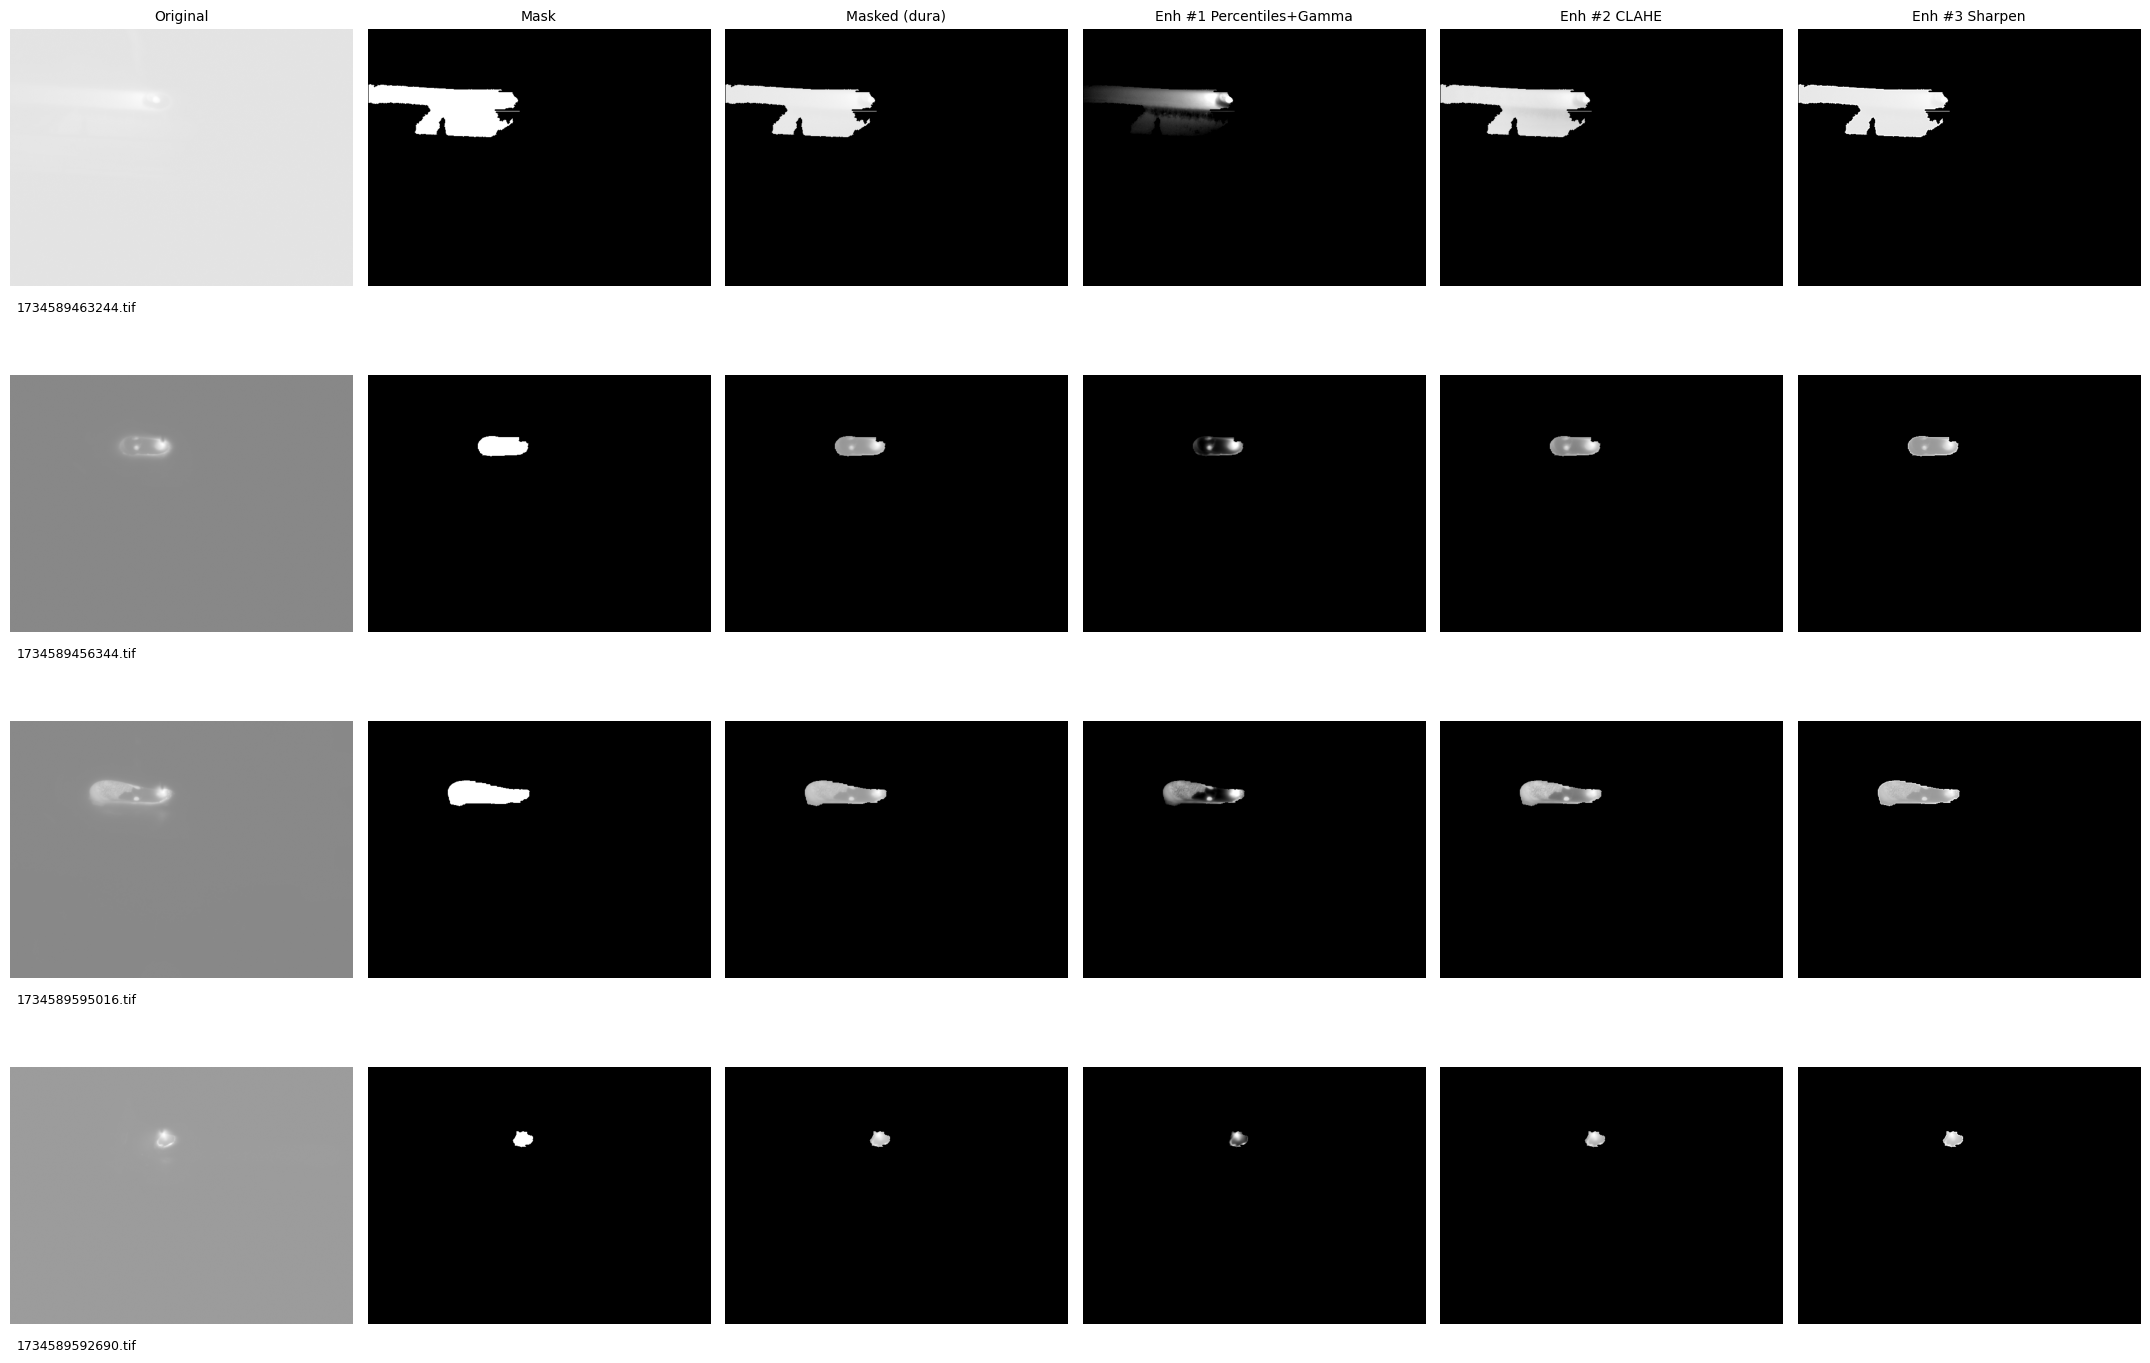

In [76]:
import os, glob, random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Enhancers (1-2-3)
# ----------------------------
def enhance_roi_percentile(gray, mask, p_low=2, p_high=98, gamma=0.75):
    g = gray.astype(np.float32)
    roi = mask > 0
    out = np.zeros_like(g, dtype=np.float32)

    if roi.sum() == 0:
        return np.zeros_like(gray, dtype=np.uint8)

    vals = g[roi]
    lo = np.percentile(vals, p_low)
    hi = np.percentile(vals, p_high)
    if hi - lo < 1e-6:
        return np.zeros_like(gray, dtype=np.uint8)

    x = (g - lo) / (hi - lo)
    x = np.clip(x, 0, 1)
    x = x ** gamma

    out[roi] = x[roi] * 255.0
    return out.astype(np.uint8)

def enhance_roi_clahe(gray, mask, clipLimit=2.0, tileGridSize=(8,8)):
    # Convertir a 8-bit SOLO para visualización (CLAHE trabaja en 8-bit)
    if gray.dtype != np.uint8:
        g8 = cv2.convertScaleAbs(gray, alpha=255.0 / max(1, float(gray.max())))
    else:
        g8 = gray

    roi = mask > 0
    out = np.zeros_like(g8, dtype=np.uint8)
    if roi.sum() == 0:
        return out

    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    eq = clahe.apply(g8)

    out[roi] = eq[roi]
    return out

def enhance_roi_sharpen(gray_u8, mask, amount=1.2):
    roi = mask > 0
    out = gray_u8.copy()

    blur = cv2.GaussianBlur(gray_u8, (0,0), 1.0)
    sharp = cv2.addWeighted(gray_u8, 1 + amount, blur, -amount, 0)

    out[roi] = sharp[roi]
    return out

# ----------------------------
# Masked (duro) helper
# ----------------------------
def apply_mask_preserve_dtype(gray, mask):
    # mask: 0/255 uint8
    if gray.dtype == np.uint8:
        return cv2.bitwise_and(gray, gray, mask=mask)
    else:
        mask01 = (mask > 0).astype(np.uint8)
        return (gray * mask01).astype(gray.dtype)

# ----------------------------
# Visualizador: N random
# ----------------------------
def demo_roi_enhancements_random(TRAIN_DIR="train", n=5, seed=42,
                                 k=3, thr=30, dist_frac=0.35, invert=False):
    exts = ("*.tif", "*.tiff")
    paths = []
    for e in exts:
        paths += glob.glob(os.path.join(TRAIN_DIR, "**", e), recursive=True)
    if len(paths) == 0:
        raise FileNotFoundError(f"No encontré TIFF en: {TRAIN_DIR}")

    random.seed(seed)
    sample = random.sample(paths, k=min(n, len(paths)))

    titles = [
        "Original",
        "Mask",
        "Masked (dura)",
        "Enh #1 Percentiles+Gamma",
        "Enh #2 CLAHE",
        "Enh #3 Sharpen"
    ]

    fig, axes = plt.subplots(len(sample), len(titles), figsize=(3.6*len(titles), 3.6*len(sample)))
    if len(sample) == 1:
        axes = np.expand_dims(axes, 0)

    for i, p in enumerate(sample):
        img = cv2.imread(p, cv2.IMREAD_UNCHANGED)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img

        # --- máscara ROI ---
        out = watershed_pipeline_steps(gray, k=k, thr=thr, dist_frac=dist_frac, invert=invert)
        mask = out["final"].astype(np.uint8)

        # --- masked duro ---
        masked = apply_mask_preserve_dtype(gray, mask)

        # Para visualizar/sharpen conviene tener una versión 8-bit
        if masked.dtype != np.uint8:
            masked_u8 = cv2.convertScaleAbs(masked, alpha=255.0 / max(1, float(masked.max())))
            gray_u8   = cv2.convertScaleAbs(gray,   alpha=255.0 / max(1, float(gray.max())))
        else:
            masked_u8 = masked
            gray_u8 = gray

        # --- mejoras ---
        enh1 = enhance_roi_percentile(masked, mask, p_low=2, p_high=98, gamma=0.75)
        enh2 = enhance_roi_clahe(masked, mask, clipLimit=2.0, tileGridSize=(8,8))
        enh3 = enhance_roi_sharpen(masked_u8, mask, amount=1.2)

        # --- plot ---
        imgs_to_show = [gray_u8, mask, masked_u8, enh1, enh2, enh3]
        for j, (tt, imshow_img) in enumerate(zip(titles, imgs_to_show)):
            ax = axes[i, j]
            ax.axis("off")
            ax.imshow(imshow_img, cmap="gray", vmin=0, vmax=255)
            if i == 0:
                ax.set_title(tt, fontsize=10)

        # nombre del archivo como etiqueta de fila
        axes[i, 0].text(0.02, -0.10, os.path.basename(p),
                        transform=axes[i, 0].transAxes, fontsize=9)

    plt.tight_layout()
    plt.show()

# ---- Ejecuta demo ----
demo_roi_enhancements_random(TRAIN_DIR="train", n=4, seed=42, k=3, thr=30, dist_frac=0.35, invert=False)

Se observa que el resultado que mas difiere a la mascara inicial es Enh #1 Percentiles+Gamma, se aplica a todo el test y train

In [ ]:
import os, glob
import cv2
import numpy as np
from pathlib import Path

# =================== CONFIG ===================
TRAIN_DIR = r"train"
TEST_DIR  = r"test"

TRAIN_MASK_DIR = r"train_masks_ws"
TEST_MASK_DIR  = r"test_masks_ws"

TRAIN_ENH_DIR  = r"train_roi_enh1"
TEST_ENH_DIR   = r"test_roi_enh1"

EXTS = ("*.tif", "*.tiff")

# Watershed 
WS_K = 3
WS_THR = 30
WS_DIST_FRAC = 0.35
WS_INVERT = False

# Método 1 (Percentiles + Gamma)
P_LOW  = 2
P_HIGH = 98
GAMMA  = 0.75
# =============================================

def ensure_dir(p): os.makedirs(p, exist_ok=True)

def norm_u8(x):
    x = x.astype(np.float32)
    mn, mx = np.min(x), np.max(x)
    if mx - mn < 1e-6:
        return np.zeros_like(x, dtype=np.uint8)
    return ((x - mn) / (mx - mn) * 255).astype(np.uint8)

def roi_mask_watershed(gray, k=3, thr=30, invert=False, open_ks=3, open_iter=1, dist_frac=0.35):
    g8 = norm_u8(gray)
    k = k if k % 2 == 1 else k + 1
    blur = cv2.GaussianBlur(g8, (k, k), 0)

    mode = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, roi_bin = cv2.threshold(blur, thr, 255, mode)

    if open_ks and open_ks > 1:
        open_ks = open_ks if open_ks % 2 == 1 else open_ks + 1
        se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_ks, open_ks))
        roi_bin = cv2.morphologyEx(roi_bin, cv2.MORPH_OPEN, se, iterations=open_iter)

    img_color = cv2.cvtColor(g8, cv2.COLOR_GRAY2BGR)

    se_bg = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    sure_bg = cv2.dilate(roi_bin, se_bg, iterations=2)

    dist = cv2.distanceTransform(roi_bin, cv2.DIST_L2, 5)
    dist_norm = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)
    _, sure_fg = cv2.threshold(dist_norm, dist_frac, 1.0, cv2.THRESH_BINARY)
    sure_fg = (sure_fg * 255).astype(np.uint8)

    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers.astype(np.int32) + 1
    markers[unknown == 255] = 0

    ws = cv2.watershed(img_color, markers)

    final = np.zeros_like(g8, dtype=np.uint8)
    final[ws > 1] = 255
    return final

def enhance_roi_percentile(gray, mask, p_low=2, p_high=98, gamma=0.75):
    g = gray.astype(np.float32)
    roi = mask > 0
    out = np.zeros_like(g, dtype=np.float32)

    if roi.sum() == 0:
        return np.zeros_like(gray, dtype=np.uint8)

    vals = g[roi]
    lo = np.percentile(vals, p_low)
    hi = np.percentile(vals, p_high)
    if hi - lo < 1e-6:
        return np.zeros_like(gray, dtype=np.uint8)

    x = (g - lo) / (hi - lo)
    x = np.clip(x, 0, 1) ** gamma

    out[roi] = x[roi] * 255.0
    return out.astype(np.uint8)

def process_split_to_masks_and_enh(src_dir, mask_dir, enh_dir):
    ensure_dir(mask_dir); ensure_dir(enh_dir)

    paths = []
    for e in EXTS:
        paths += glob.glob(os.path.join(src_dir, "**", e), recursive=True)
    if len(paths) == 0:
        raise FileNotFoundError(f"No encontré TIFF en: {src_dir}")

    ok, fail = 0, 0
    for i, p in enumerate(paths, 1):
        try:
            base = Path(p).stem
            mask_path = os.path.join(mask_dir, f"{base}_mask.png")
            enh_path  = os.path.join(enh_dir,  f"{base}_enh1.png")

            img = cv2.imread(p, cv2.IMREAD_UNCHANGED)
            if img is None:
                fail += 1
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img

            # máscara (si no existe)
            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            else:
                mask = roi_mask_watershed(gray, k=WS_K, thr=WS_THR, invert=WS_INVERT, dist_frac=WS_DIST_FRAC)
                cv2.imwrite(mask_path, mask)

            # enhanced método 1
            enh = enhance_roi_percentile(gray, mask, p_low=P_LOW, p_high=P_HIGH, gamma=GAMMA)
            cv2.imwrite(enh_path, enh)

            ok += 1
            if i % 50 == 0 or i == len(paths):
                print(f"[{src_dir}] {i}/{len(paths)} OK={ok} FAIL={fail}")
        except Exception as ex:
            print("Error:", p, ex)
            fail += 1

    print(f"✅ Terminado {src_dir} -> masks:{mask_dir} | enh:{enh_dir}")

# RUN
process_split_to_masks_and_enh(TRAIN_DIR, TRAIN_MASK_DIR, TRAIN_ENH_DIR)
process_split_to_masks_and_enh(TEST_DIR,  TEST_MASK_DIR,  TEST_ENH_DIR)

[train] 50/277 OK=50 FAIL=0
[train] 100/277 OK=100 FAIL=0
[train] 150/277 OK=150 FAIL=0
[train] 200/277 OK=200 FAIL=0
[train] 250/277 OK=250 FAIL=0
[train] 277/277 OK=277 FAIL=0
✅ Terminado train -> masks:train_masks_ws | enh:train_roi_enh1
[test] 50/70 OK=50 FAIL=0
[test] 70/70 OK=70 FAIL=0
✅ Terminado test -> masks:test_masks_ws | enh:test_roi_enh1


Se entrena el modelo con las nuevas imagenes del train, se crea modelos para 4 y 7 clusters

In [88]:
import os, glob, random
import cv2
import numpy as np

def train_kmeans_centers_roi_from_enh(enh_dir, mask_dir, n_clusters=4,
                                      max_imgs=400, samples_per_img=8000, seed=42,
                                      out_path="kmeans_centers_train_enh1_roi.npy"):
    paths = glob.glob(os.path.join(enh_dir, "**", "*.png"), recursive=True)
    if len(paths) == 0:
        raise FileNotFoundError(f"No encontré PNG en: {enh_dir}")

    random.seed(seed)
    paths = random.sample(paths, k=min(max_imgs, len(paths)))

    samples = []
    for p in paths:
        # <base>_enh1.png -> <base>
        name = os.path.basename(p)
        base = name.replace("_enh1.png", "") if name.endswith("_enh1.png") else os.path.splitext(name)[0]
        mask_path = os.path.join(mask_dir, f"{base}_mask.png")

        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)          # enhanced u8
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) # 0/255
        if img is None or mask is None:
            continue

        roi = mask > 0
        pix = img[roi]
        if pix.size == 0:
            continue

        n = min(samples_per_img, pix.size)
        idx = np.random.choice(pix.size, size=n, replace=False)
        samples.append(pix[idx])

    if len(samples) == 0:
        raise RuntimeError("No pude recolectar muestras ROI. Revisa enh_dir/mask_dir.")

    X = np.concatenate(samples).astype(np.float32).reshape(-1,1)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 200, 0.1)
    _, labels, centers = cv2.kmeans(X, n_clusters, None, criteria, 10, cv2.KMEANS_PP_CENTERS)

    centers = np.sort(centers.flatten())
    np.save(out_path, centers)
    print(f"✅ KMeans K={n_clusters} guardado:", out_path)
    print("Centers:", centers)
    #print("Muestras ROI:", X.shape[0])
    return centers

centers4 = train_kmeans_centers_roi_from_enh(
    enh_dir="train_roi_enh1", mask_dir="train_masks_ws",
    n_clusters=4, out_path="kmeans_centers_train_enh1_roi_4.npy"
)

centers7 = train_kmeans_centers_roi_from_enh(
    enh_dir="train_roi_enh1", mask_dir="train_masks_ws",
    n_clusters=7, out_path="kmeans_centers_train_enh1_roi_7.npy"
)

✅ KMeans K=4 guardado: kmeans_centers_train_enh1_roi_4.npy
Centers: [ 28.739624  86.69568  151.09125  219.5296  ]
✅ KMeans K=7 guardado: kmeans_centers_train_enh1_roi_7.npy
Centers: [ 16.978682  51.430325  84.839516 119.83875  155.21669  192.30402
 237.36884 ]


Se imprime centors, maximos y minimos 

In [ ]:
import os, glob
import cv2
import numpy as np
import pandas as pd

def cluster_minmax_table(enh_dir, mask_dir, centers_npy, out_csv=None):
    centers = np.load(centers_npy).astype(np.float32)
    K = len(centers)

    # init
    cmin = np.full(K, np.inf, dtype=np.float32)
    cmax = np.full(K, -np.inf, dtype=np.float32)
    count = np.zeros(K, dtype=np.int64)

    paths = glob.glob(os.path.join(enh_dir, "**", "*.png"), recursive=True)
    if len(paths) == 0:
        raise FileNotFoundError(f"No encontré PNG en: {enh_dir}")

    for p in paths:
        name = os.path.basename(p)
        base = name.replace("_enh1.png", "") if name.endswith("_enh1.png") else os.path.splitext(name)[0]
        mask_path = os.path.join(mask_dir, f"{base}_mask.png")

        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)          # enhanced u8
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) # 0/255
        if img is None or mask is None:
            continue

        roi = mask > 0
        pix = img[roi]
        if pix.size == 0:
            continue

        # asignación a centers por distancia (intensidad)
        pix_f = pix.astype(np.float32)[:, None]        # (N,1)
        d = np.abs(pix_f - centers[None, :])           # (N,K)
        lab = np.argmin(d, axis=1).astype(np.int32)    # (N,)

        # actualizar min/max por cluster
        for k in range(K):
            pk = pix[lab == k]
            if pk.size == 0:
                continue
            vmin = float(pk.min())
            vmax = float(pk.max())
            if vmin < cmin[k]: cmin[k] = vmin
            if vmax > cmax[k]: cmax[k] = vmax
            count[k] += pk.size

    # manejar clusters sin datos
    cmin[np.isinf(cmin)] = np.nan
    cmax[cmax == -np.inf] = np.nan

    df = pd.DataFrame({
        "cluster": np.arange(K),
        "center": centers,
        "min": cmin,
        "max": cmax,
        "count_pixels": count
    })

    # redondeo 
    df["center"] = df["center"].round(2)
    df["min"] = df["min"].round(0)
    df["max"] = df["max"].round(0)

    if out_csv:
        df.to_csv(out_csv, index=False)
        print("CSV guardado:", out_csv)

    return df

# ---- K=4 ----
df4 = cluster_minmax_table(
    enh_dir="train_roi_enh1",
    mask_dir="train_masks_ws",
    centers_npy="kmeans_centers_train_enh1_roi_4.npy",
    out_csv="kmeans_table_k4.csv"
)
print("\nTabla K=4")
display(df4)  # en Jupyter

# ---- K=7 ----
df7 = cluster_minmax_table(
    enh_dir="train_roi_enh1",
    mask_dir="train_masks_ws",
    centers_npy="kmeans_centers_train_enh1_roi_7.npy",
    out_csv="kmeans_table_k7.csv"
)
print("\nTabla K=7")
display(df7)

CSV guardado: kmeans_table_k4.csv

Tabla K=4


,cluster,center,min,max,count_pixels
0,0,29.750000,0.0,59.0,792423
1,1,89.190002,60.0,121.0,822403
2,2,153.050003,122.0,186.0,781199
3,3,220.160004,187.0,255.0,548256


CSV guardado: kmeans_table_k7.csv

Tabla K=7


,cluster,center,min,max,count_pixels
0,0,16.420000,0.0,33.0,446467
1,1,50.900002,34.0,68.0,481449
2,2,85.839996,69.0,104.0,472969
3,3,122.349998,105.0,140.0,443520
4,4,158.149994,141.0,176.0,435590
5,5,194.809998,177.0,216.0,382199
6,6,238.419998,217.0,255.0,282087


Se aplica nuevos modelos a test

In [ ]:
import os, glob
import cv2
import numpy as np
from pathlib import Path

# ---------------- CONFIG ----------------
TEST_DIR = r"test"

TEST_MASK_DIR = r"test_masks_ws"
TEST_ENH_DIR  = r"test_roi_enh1"

OUT_TEST_4 = r"test_4_enh1_cluster"
OUT_TEST_7 = r"test_7_enh1_cluster"

CENTERS_4 = r"kmeans_centers_train_enh1_roi_4.npy"
CENTERS_7 = r"kmeans_centers_train_enh1_roi_7.npy"

EXTS = ("*.tif","*.tiff")

# Watershed ROI params 
WS_K = 3
WS_THR = 30
WS_DIST_FRAC = 0.35
WS_INVERT = False

# Método 1 (Percentiles+Gamma)
P_LOW, P_HIGH, GAMMA = 2, 98, 0.75

COLORMAP = cv2.COLORMAP_TURBO
# ---------------------------------------

def ensure_dir(p): os.makedirs(p, exist_ok=True)

def norm_u8(x):
    x = x.astype(np.float32)
    mn, mx = np.min(x), np.max(x)
    if mx - mn < 1e-6:
        return np.zeros_like(x, dtype=np.uint8)
    return ((x - mn) / (mx - mn) * 255).astype(np.uint8)

def roi_mask_watershed(gray, k=3, thr=30, invert=False, open_ks=3, open_iter=1, dist_frac=0.35):
    g8 = norm_u8(gray)
    k = k if k % 2 == 1 else k + 1
    blur = cv2.GaussianBlur(g8, (k, k), 0)

    mode = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, roi_bin = cv2.threshold(blur, thr, 255, mode)

    if open_ks and open_ks > 1:
        open_ks = open_ks if open_ks % 2 == 1 else open_ks + 1
        se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_ks, open_ks))
        roi_bin = cv2.morphologyEx(roi_bin, cv2.MORPH_OPEN, se, iterations=open_iter)

    img_color = cv2.cvtColor(g8, cv2.COLOR_GRAY2BGR)

    se_bg = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    sure_bg = cv2.dilate(roi_bin, se_bg, iterations=2)

    dist = cv2.distanceTransform(roi_bin, cv2.DIST_L2, 5)
    dist_norm = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)
    _, sure_fg = cv2.threshold(dist_norm, dist_frac, 1.0, cv2.THRESH_BINARY)
    sure_fg = (sure_fg * 255).astype(np.uint8)

    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers.astype(np.int32) + 1
    markers[unknown == 255] = 0

    ws = cv2.watershed(img_color, markers)

    final = np.zeros_like(g8, dtype=np.uint8)
    final[ws > 1] = 255
    return final

def enhance_roi_percentile(gray, mask, p_low=2, p_high=98, gamma=0.75):
    g = gray.astype(np.float32)
    roi = mask > 0
    out = np.zeros_like(g, dtype=np.float32)

    if roi.sum() == 0:
        return np.zeros_like(gray, dtype=np.uint8)

    vals = g[roi]
    lo = np.percentile(vals, p_low)
    hi = np.percentile(vals, p_high)
    if hi - lo < 1e-6:
        return np.zeros_like(gray, dtype=np.uint8)

    x = (g - lo) / (hi - lo)
    x = np.clip(x, 0, 1) ** gamma
    out[roi] = x[roi] * 255.0
    return out.astype(np.uint8)

def get_test_paths():
    paths = []
    for e in EXTS:
        paths += glob.glob(os.path.join(TEST_DIR, "**", e), recursive=True)
    if len(paths) == 0:
        raise FileNotFoundError(f"No encontré TIFF en: {TEST_DIR}")
    return paths

def make_masks_and_enh_test():
    ensure_dir(TEST_MASK_DIR); ensure_dir(TEST_ENH_DIR)
    paths = get_test_paths()

    for i, p in enumerate(paths, 1):
        base = Path(p).stem
        mask_path = os.path.join(TEST_MASK_DIR, f"{base}_mask.png")
        enh_path  = os.path.join(TEST_ENH_DIR,  f"{base}_enh1.png")

        img = cv2.imread(p, cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img

        # máscara
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        else:
            mask = roi_mask_watershed(gray, k=WS_K, thr=WS_THR, invert=WS_INVERT, dist_frac=WS_DIST_FRAC)
            cv2.imwrite(mask_path, mask)

        # enhanced
        enh = enhance_roi_percentile(gray, mask, p_low=P_LOW, p_high=P_HIGH, gamma=GAMMA)
        cv2.imwrite(enh_path, enh)

        if i % 50 == 0 or i == len(paths):
            print(f"[TEST masks+enh] {i}/{len(paths)}")

def clusterize_test_to_folder(centers_npy, out_dir):
    ensure_dir(out_dir)
    centers = np.load(centers_npy).astype(np.float32)
    K = len(centers)

    enh_paths = glob.glob(os.path.join(TEST_ENH_DIR, "**", "*.png"), recursive=True)
    if len(enh_paths) == 0:
        raise FileNotFoundError(f"No encontré enhanced en: {TEST_ENH_DIR}")

    for i, p in enumerate(enh_paths, 1):
        name = os.path.basename(p)
        base = name.replace("_enh1.png", "") if name.endswith("_enh1.png") else Path(p).stem
        mask_path = os.path.join(TEST_MASK_DIR, f"{base}_mask.png")

        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if img is None or mask is None:
            continue

        roi = mask > 0
        labels_vis = np.zeros_like(img, dtype=np.uint8)   # 0 fondo, 1..K clusters

        if roi.sum() > 0:
            pix = img[roi].astype(np.float32)[:, None]
            d = np.abs(pix - centers[None, :])
            lab = np.argmin(d, axis=1).astype(np.uint8)
            labels_vis[roi] = lab + 1

        scaled = (labels_vis.astype(np.float32) * (255.0 / max(1, K))).astype(np.uint8)
        color = cv2.applyColorMap(scaled, COLORMAP)
        color[labels_vis == 0] = (0, 0, 0)

        out_path = os.path.join(out_dir, f"{base}_k{K}_cluster.png")
        cv2.imwrite(out_path, color)

        if i % 100 == 0 or i == len(enh_paths):
            print(f"[{out_dir}] {i}/{len(enh_paths)}")

# ---------------- RUN ----------------
make_masks_and_enh_test()

clusterize_test_to_folder(CENTERS_4, OUT_TEST_4)
clusterize_test_to_folder(CENTERS_7, OUT_TEST_7)

print("✅ Listo:")
print(" - Masks:", TEST_MASK_DIR)
print(" - Enhanced:", TEST_ENH_DIR)
print(" - Test K4:", OUT_TEST_4)
print(" - Test K7:", OUT_TEST_7)

[TEST masks+enh] 50/70
[TEST masks+enh] 70/70
[test_4_enh1_cluster] 70/70
[test_7_enh1_cluster] 70/70
✅ Listo:
 - Masks: test_masks_ws
 - Enhanced: test_roi_enh1
 - Test K4: test_4_enh1_cluster
 - Test K7: test_7_enh1_cluster
